# 🏥 Tech Challenge Fase 4 — Obesity Predictor
## Pipeline de Machine Learning: EDA + Feature Engineering + Treinamento

**Objetivo:** Prever o nível de obesidade de pacientes em 7 categorias usando **apenas hábitos de vida** — sem usar Peso e Altura, que determinariam o label diretamente (data leakage).

**Features utilizadas (14):** Age · Gender · family_history · FAVC · FCVC · NCP · CAEC · SMOKE · CH2O · SCC · FAF · TUE · CALC · MTRANS

**Dataset:** `obesity.csv` — 2.111 registros × 7 classes balanceadas

---

## 0. Setup e Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)

print('✅ Imports OK')

✅ Imports OK


---
## 1. Carregamento e Limpeza

In [25]:
df_raw = pd.read_csv('../data/obesity.csv')
print(f'Shape original: {df_raw.shape}')
print(f'Duplicatas: {df_raw.duplicated().sum()}')
print(f'Nulos: {df_raw.isnull().sum().sum()}')

Shape original: (2111, 17)
Duplicatas: 24
Nulos: 0


In [26]:
# Remover duplicatas e colunas com data leakage (Weight, Height)
df = df_raw.drop_duplicates().drop(columns=['Weight', 'Height']).reset_index(drop=True)
print(f'Shape após limpeza: {df.shape}')
df.head()

Shape após limpeza: (2087, 15)


,Gender,Age,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [27]:
# Arredondar variáveis com ruído sintético (valores decimais gerados por SMOTE)
ordinal_num_cols = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df[ordinal_num_cols] = df[ordinal_num_cols].round(0).astype(int)
print('✅ Variáveis ordinais arredondadas')
df[ordinal_num_cols].describe()

✅ Variáveis ordinais arredondadas


,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,2.425970,2.703402,2.011500,1.009104,0.669861
std,0.585177,0.797108,0.685322,0.898712,0.673970
min,1.000000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,3.000000,2.000000,0.000000,0.000000
50%,2.000000,3.000000,2.000000,1.000000,1.000000
75%,3.000000,3.000000,2.000000,2.000000,1.000000
max,3.000000,4.000000,3.000000,3.000000,2.000000


---
## 2. Análise Exploratória (EDA)
### 2.1 Distribuição do Target

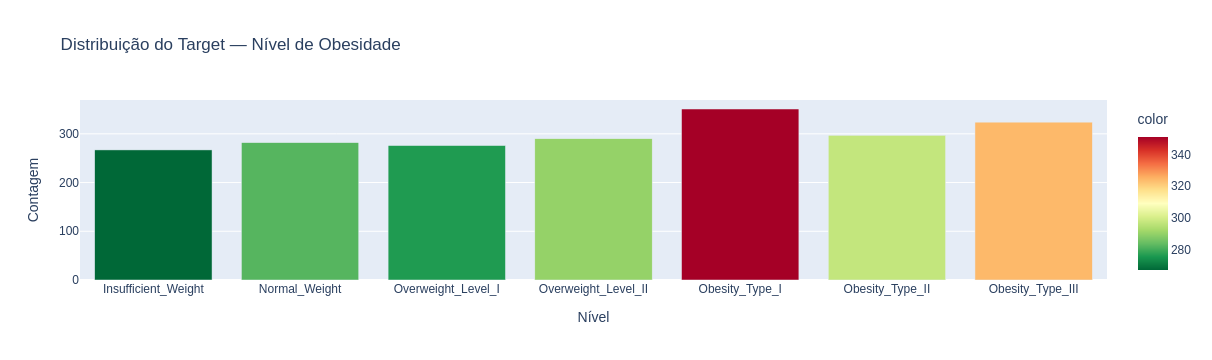


Distribuição percentual:
Obesity
Insufficient_Weight    12.8
Normal_Weight          13.5
Overweight_Level_I     13.2
Overweight_Level_II    13.9
Obesity_Type_I         16.8
Obesity_Type_II        14.2
Obesity_Type_III       15.5


In [28]:
TARGET_ORDER = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I', 'Overweight_Level_II',
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

counts = df['Obesity'].value_counts().reindex(TARGET_ORDER)
fig = px.bar(
    x=counts.index, y=counts.values,
    title='Distribuição do Target — Nível de Obesidade',
    labels={'x': 'Nível', 'y': 'Contagem'},
    color=counts.values, color_continuous_scale='RdYlGn_r'
)
fig.show()

print('\nDistribuição percentual:')
print((df['Obesity'].value_counts(normalize=True) * 100).round(1).reindex(TARGET_ORDER).to_string())

### 2.2 Variável numérica: Age

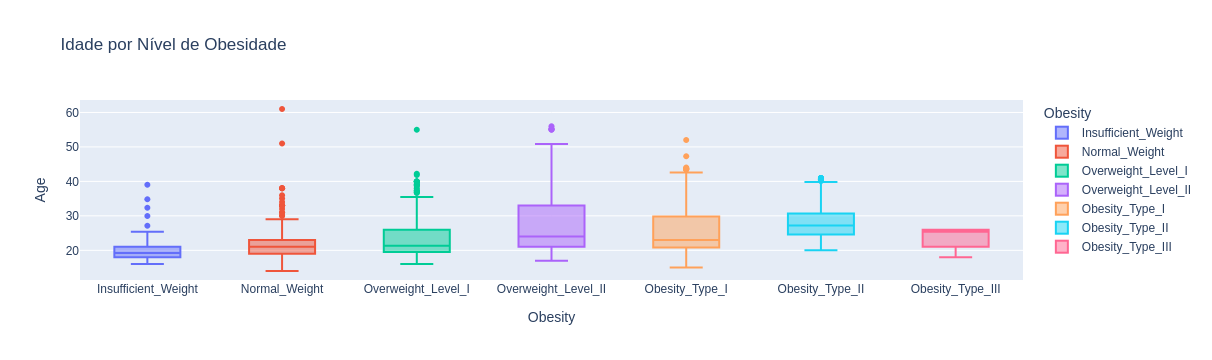

In [29]:
fig = px.box(df, x='Obesity', y='Age', category_orders={'Obesity': TARGET_ORDER},
             color='Obesity', title='Idade por Nível de Obesidade')
fig.show()

### 2.3 Variáveis ordinais de hábitos

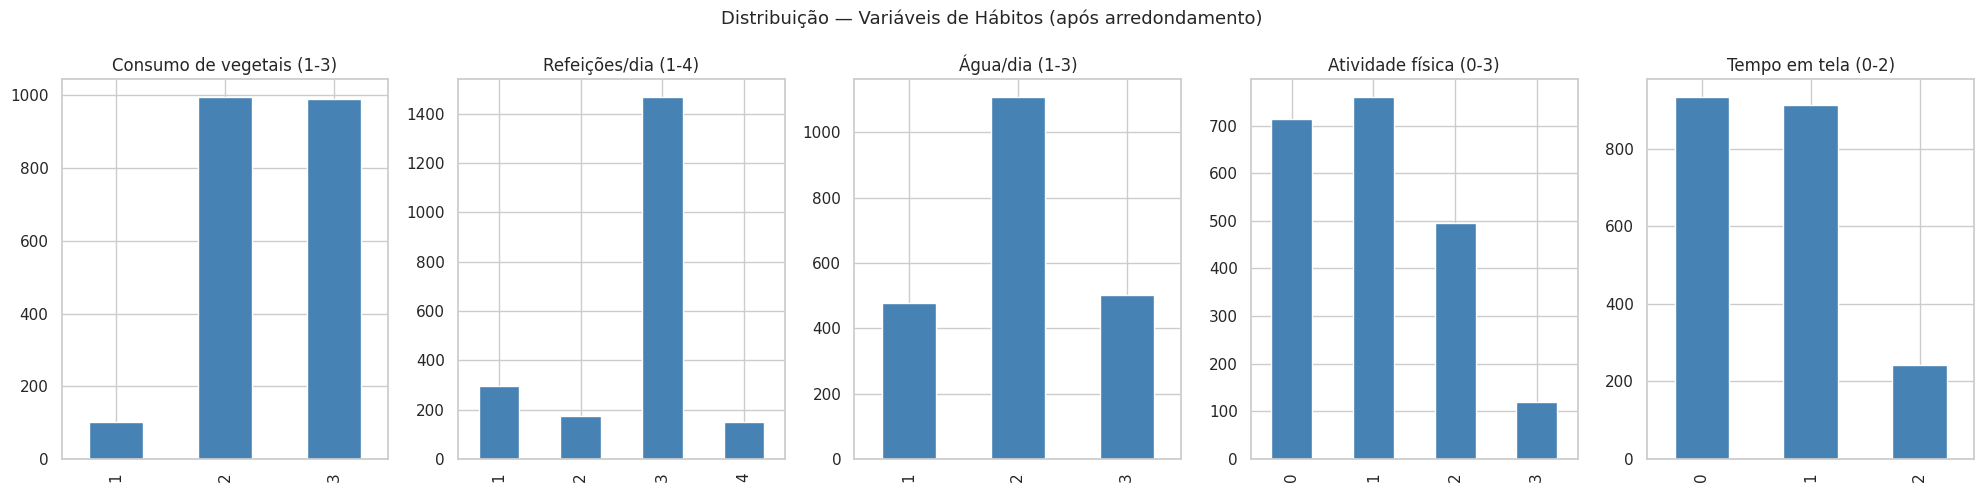

In [30]:
habit_labels = {
    'FCVC': 'Consumo de vegetais (1-3)',
    'NCP':  'Refeições/dia (1-4)',
    'CH2O': 'Água/dia (1-3)',
    'FAF':  'Atividade física (0-3)',
    'TUE':  'Tempo em tela (0-2)'
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, (col, label) in zip(axes, habit_labels.items()):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(label)
    ax.set_xlabel('')
plt.suptitle('Distribuição — Variáveis de Hábitos (após arredondamento)', fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 Variáveis categóricas

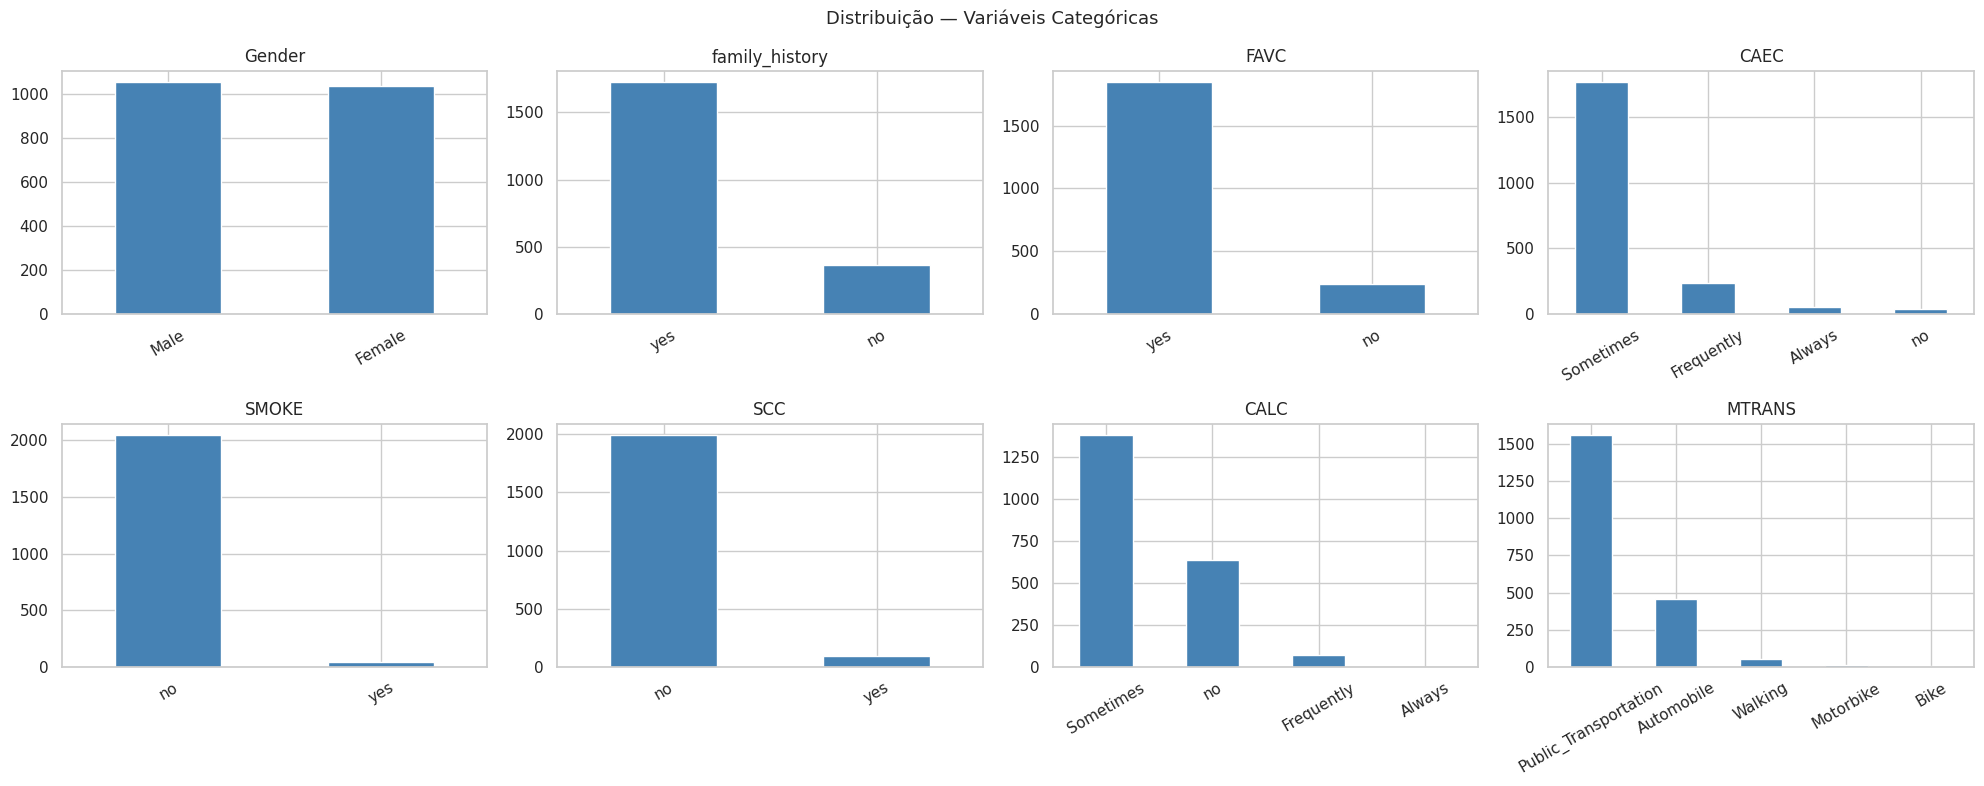

In [31]:
cat_cols = ['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Distribuição — Variáveis Categóricas', fontsize=13)
plt.tight_layout()
plt.show()

### 2.5 Hábitos por nível de obesidade — análise cruzada

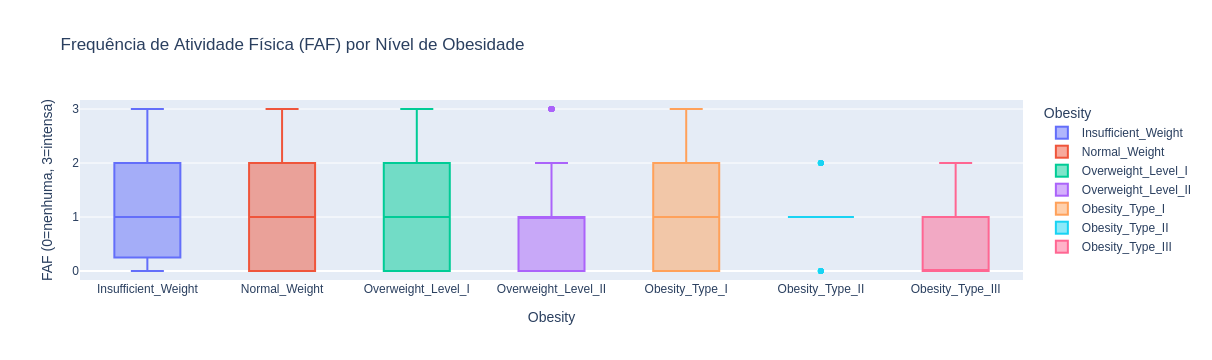

In [32]:
# FAF (atividade física) por nível de obesidade — hipótese central
fig = px.box(df, x='Obesity', y='FAF', category_orders={'Obesity': TARGET_ORDER},
             color='Obesity',
             title='Frequência de Atividade Física (FAF) por Nível de Obesidade',
             labels={'FAF': 'FAF (0=nenhuma, 3=intensa)'})
fig.show()

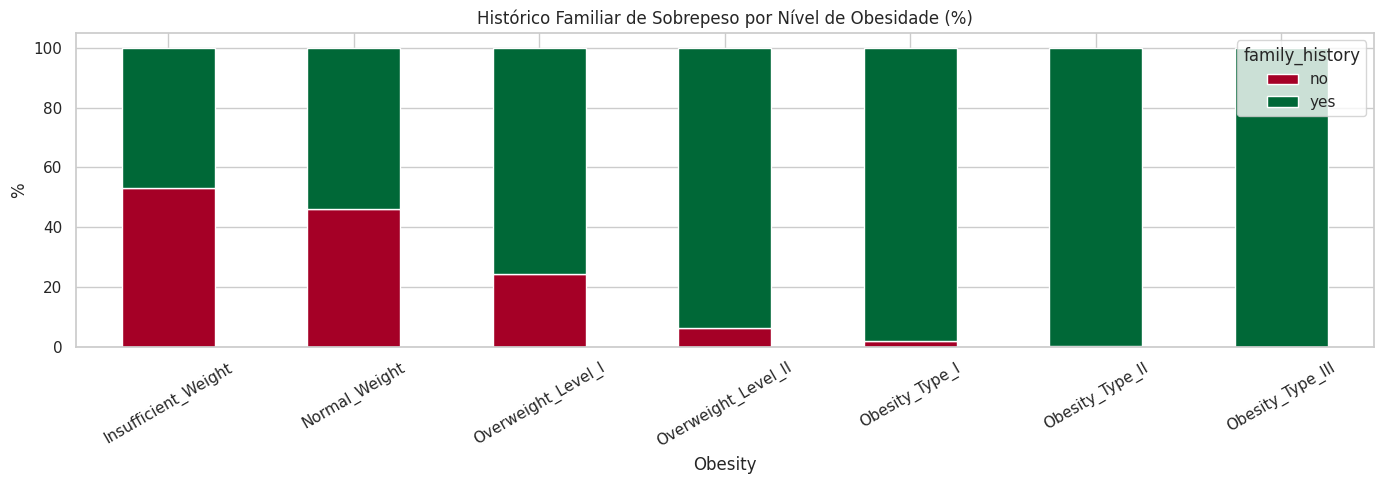

In [33]:
# Histórico familiar por classe — preditor esperado
cross = pd.crosstab(df['family_history'], df['Obesity'], normalize='columns') * 100
cross = cross[TARGET_ORDER]
cross.T.plot(kind='bar', stacked=True, figsize=(14, 5), colormap='RdYlGn')
plt.title('Histórico Familiar de Sobrepeso por Nível de Obesidade (%)')
plt.ylabel('%')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 3. Pré-processamento e Pipeline

In [34]:
TARGET = 'Obesity'

# Features — SEM Weight e Height
numeric_cols  = ['Age']
ordinal_num   = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
binary_cols   = ['Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC']
ordered_cols  = ['CAEC', 'CALC']
onehot_cols   = ['MTRANS']

FEATURES = numeric_cols + ordinal_num + binary_cols + ordered_cols + onehot_cols
print(f'Features ({len(FEATURES)}): {FEATURES}')

X = df[FEATURES].copy()
y = df[TARGET].copy()

caec_order = [['no', 'Sometimes', 'Frequently', 'Always']]
calc_order = [['no', 'Sometimes', 'Frequently', 'Always']]

preprocessor = ColumnTransformer(transformers=[
    ('num',     StandardScaler(),                                     numeric_cols + ordinal_num),
    ('binary',  OrdinalEncoder(),                                     binary_cols),
    ('ordered', OrdinalEncoder(categories=caec_order + calc_order),  ordered_cols),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
])

le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f'Classes: {list(le.classes_)}')

Features (14): ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC', 'CAEC', 'CALC', 'MTRANS']
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (1669, 14) | Teste: (418, 14)


---
## 4. Comparação de Modelos (Cross-Validation 5-fold)

In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss', n_jobs=-1),
}

cv_results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25} → {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression       → 0.5710 ± 0.0390
Random Forest             → 0.7969 ± 0.0084
XGBoost                   → 0.8059 ± 0.0193


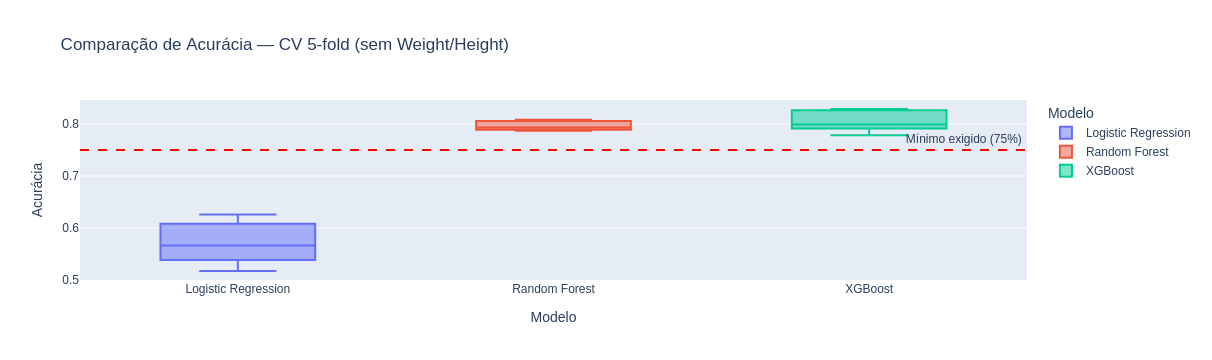

In [37]:
results_df = pd.DataFrame(cv_results).melt(var_name='Modelo', value_name='Acurácia')
fig = px.box(results_df, x='Modelo', y='Acurácia',
             title='Comparação de Acurácia — CV 5-fold (sem Weight/Height)',
             color='Modelo')
fig.add_hline(y=0.75, line_dash='dash', line_color='red',
              annotation_text='Mínimo exigido (75%)')
fig.show()

---
## 5. Treinar e Avaliar o Melhor Modelo

In [38]:
# Selecionar modelo com maior média de CV
BEST_MODEL_NAME = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'Melhor modelo (CV): {BEST_MODEL_NAME} → {cv_results[BEST_MODEL_NAME].mean():.4f}')

best_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', models[BEST_MODEL_NAME])
])
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'\nAcurácia no teste: {acc:.4f} ({acc*100:.2f}%)')
print(f'Requisito >75%: {"✅ APROVADO" if acc >= 0.75 else "❌ REPROVADO"}')

Melhor modelo (CV): XGBoost → 0.8059

Acurácia no teste: 0.7871 (78.71%)
Requisito >75%: ✅ APROVADO


In [39]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

                     precision    recall  f1-score   support

Insufficient_Weight       0.84      0.91      0.87        53
      Normal_Weight       0.61      0.63      0.62        57
     Obesity_Type_I       0.75      0.79      0.77        70
    Obesity_Type_II       0.81      0.92      0.86        60
   Obesity_Type_III       0.97      0.98      0.98        65
 Overweight_Level_I       0.73      0.69      0.71        55
Overweight_Level_II       0.77      0.57      0.65        58

           accuracy                           0.79       418
          macro avg       0.78      0.78      0.78       418
       weighted avg       0.79      0.79      0.78       418



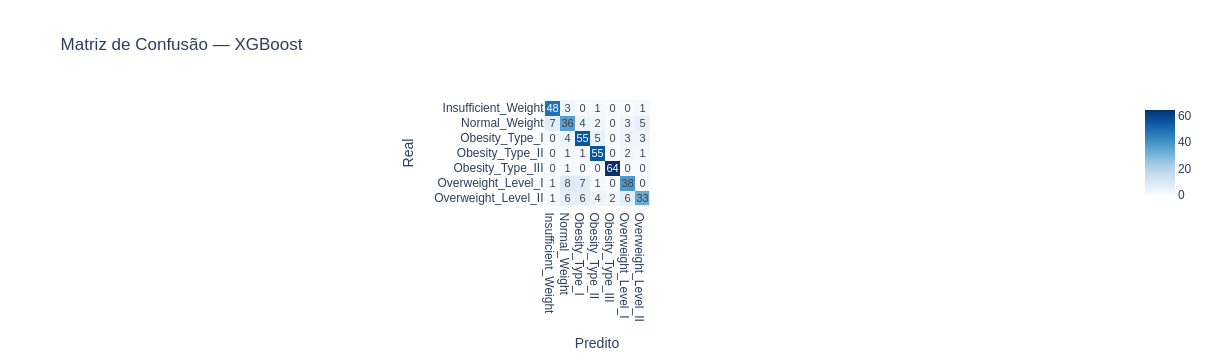

In [40]:
cm = confusion_matrix(y_test, y_pred)
fig = px.imshow(cm, text_auto=True,
                x=list(le.classes_), y=list(le.classes_),
                title=f'Matriz de Confusão — {BEST_MODEL_NAME}',
                color_continuous_scale='Blues',
                labels={'x': 'Predito', 'y': 'Real'})
fig.show()

---
## 6. Feature Importance

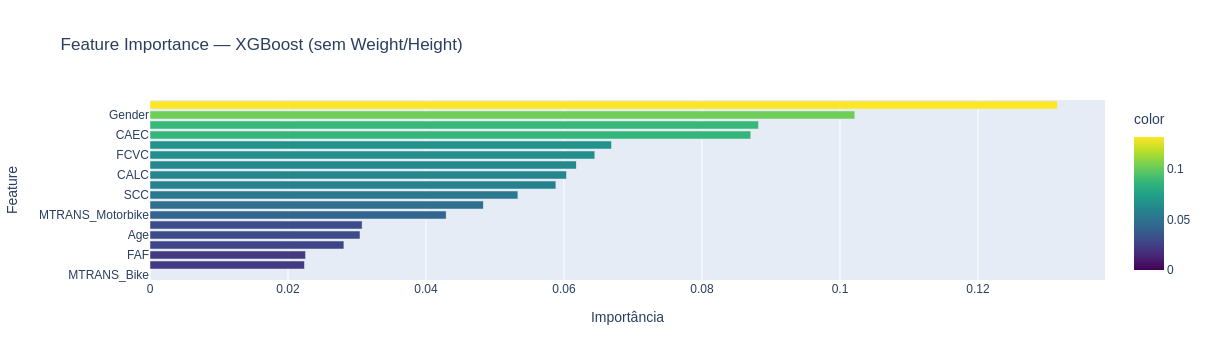


Top 5 features:
family_history       0.131490
Gender               0.102155
MTRANS_Automobile    0.088199
CAEC                 0.087079
MTRANS_Walking       0.066886
dtype: float32


In [41]:
ohe_features = (
    best_pipeline.named_steps['prep']
    .named_transformers_['ohe']
    .get_feature_names_out(onehot_cols)
    .tolist()
)
feature_names = numeric_cols + ordinal_num + binary_cols + ordered_cols + ohe_features

model_step = best_pipeline.named_steps['model']
if hasattr(model_step, 'feature_importances_'):
    importances = pd.Series(model_step.feature_importances_, index=feature_names).sort_values(ascending=False)
    fig = px.bar(
        x=importances.values, y=importances.index,
        orientation='h',
        title=f'Feature Importance — {BEST_MODEL_NAME} (sem Weight/Height)',
        labels={'x': 'Importância', 'y': 'Feature'},
        color=importances.values, color_continuous_scale='Viridis'
    )
    fig.update_layout(yaxis={'categoryorder': 'total ascending'})
    fig.show()
    print('\nTop 5 features:')
    print(importances.head())
else:
    print('Modelo não suporta feature_importances_')

---
## 7. Salvar o Modelo

In [42]:
model_artifacts = {
    'pipeline':       best_pipeline,
    'label_encoder':  le,
    'feature_names':  FEATURES,
    'target_classes': list(le.classes_),
    'model_name':     BEST_MODEL_NAME,
    'accuracy_test':  float(acc),
    'leakage_free':   True,   # Weight e Height NÃO foram usados
}

joblib.dump(model_artifacts, '../model/model_pipeline.pkl')
print(f'✅ Modelo salvo: ../model/model_pipeline.pkl')
print(f'   Modelo:    {BEST_MODEL_NAME}')
print(f'   Acurácia:  {acc:.4f}')
print(f'   Features:  {FEATURES}')
print(f'   Classes:   {list(le.classes_)}')

✅ Modelo salvo: ../model/model_pipeline.pkl
   Modelo:    XGBoost
   Acurácia:  0.7871
   Features:  ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC', 'CAEC', 'CALC', 'MTRANS']
   Classes:   ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


In [43]:
# Verificação de sanidade
loaded = joblib.load('../model/model_pipeline.pkl')
sample = X_test.iloc[:1]
pred = loaded['pipeline'].predict(sample)
print(f'✅ Modelo carregado e funcional')
print(f'   Predição de teste: {loaded["label_encoder"].inverse_transform(pred)[0]}')

✅ Modelo carregado e funcional
   Predição de teste: Obesity_Type_III


---
## 8. Conclusões

**Decisão de design:** Weight e Height foram **intencionalmente excluídos** porque essas variáveis determinam diretamente o label via BMI (data leakage). O modelo aprendeu padrões de obesidade a partir de **hábitos de vida**, o que tem valor clínico real — permite triagem de risco antes de qualquer medição física.

**Resultados:**
- Modelo escolhido: _preencher após análise_
- Acurácia (hábitos apenas): _preencher após análise_
- Features mais importantes: _preencher após análise_

**Próximos passos:**
1. App Streamlit — página de predição por hábitos
2. Dashboard analítico com insights sobre o dataset
3. Deploy no Streamlit Community Cloud